# 💪 Desafio 1: Análise de Dados de Vendas

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)

dados_vendas = {
    'Vendedor': ['Ana', 'João', 'Pedro', 'Ana', 'João', 'Pedro', 'Ana', 'João', 'Pedro', 'Ana'] * 3,
    'Produto': ['Notebook', 'Mouse', 'Teclado', 'Monitor', 'Headset'] * 6,
    'Regiao': ['Norte', 'Sul', 'Nordeste', 'Centro-Oeste', 'Sudeste'] * 6,
    'Vendas': np.random.randint(1000, 10000, 30),
    'Quantidade': np.random.randint(1, 20, 30)
}

df_vendas_completo = pd.DataFrame(dados_vendas)
print("DataFrame de vendas:")
df_vendas_completo.head(10)

DataFrame de vendas:


,Vendedor,Produto,Regiao,Vendas,Quantidade
0,Ana,Notebook,Norte,8270,12
1,João,Mouse,Sul,1860,3
2,Pedro,Teclado,Nordeste,6390,5
3,Ana,Monitor,Centro-Oeste,6191,19
4,João,Headset,Sudeste,6734,7
5,Pedro,Notebook,Norte,7265,9
6,Ana,Mouse,Sul,1466,7
7,João,Teclado,Nordeste,5426,18
8,Pedro,Monitor,Centro-Oeste,6578,4
9,Ana,Headset,Sudeste,9322,14


# Qual vendedor teve o maior número de vendas?

Para descobrir, usaremos o agrupamento por vendedor:

In [3]:
vendas_por_vendedor = df_vendas_completo.groupby('Vendedor')['Vendas'].sum()
print("Vendas totais por vendedor:")
vendas_por_vendedor

Vendas totais por vendedor:


,Vendas
Vendedor,
Ana,66264
João,40731
Pedro,51098


Portanto, Ana teve o maior número de vendas.

Desafio 2

# Qual região teve o maior faturamento total?

Vamos agrupar por região, e agregar os faturamentos:

In [4]:
faturamentos_por_regiao = df_vendas_completo.groupby('Regiao')['Vendas'].sum()
print("Vendas totais por vendedor:")
faturamentos_por_regiao

Vendas totais por vendedor:


,Vendas
Regiao,
Centro-Oeste,34611
Nordeste,29241
Norte,35414
Sudeste,35457
Sul,23370


Portanto, a Região Sudeste teve o maior faturamento total, de 35457.

# Qual é o produto mais vendido em quantidade?

Vamos agrupar por produto, e agregar as quantidades:

In [6]:
quantidade_por_produto = df_vendas_completo.groupby('Produto')['Quantidade'].sum()
print("Vendas totais por vendedor:")
quantidade_por_produto

Vendas totais por vendedor:


,Quantidade
Produto,
Headset,64
Monitor,53
Mouse,37
Notebook,70
Teclado,68


Portanto, o produto mais vendido foi o Notebook, com 70 unidades vendidas.

# Qual é a média de vendas por vendedor?

In [9]:
media_vendas_por_vendedor = df_vendas_completo.groupby('Vendedor')['Vendas'].mean()
print("Média por vendedor:")
media_vendas_por_vendedor.round(2)

Média por vendedor:


,Vendas
Vendedor,
Ana,5522.00
João,4525.67
Pedro,5677.56


# 🔧 Desafio 2: Limpeza de Dados

Dataframe com dados sujos:

In [18]:
dados_sujos = {
    'Nome': ['ana silva', 'João Souza', 'PEDRO Lima', 'Ana Silva', 'maria costa',
             'joão souza', '  Carlos Reis  ', 'Maria Costa', 'Pedro lima', None],
    'Idade': [28, 34, np.nan, 28, 45, 34, 22, 45, np.nan, 31],
    'Cidade': ['sao paulo', 'Rio de Janeiro', 'BELO HORIZONTE', 'Sao Paulo', np.nan,
               'rio de janeiro', 'Curitiba', 'belo horizonte', 'Belo Horizonte', 'Recife'],
    'Salario': [3500.0, 4200.0, 5100.0, 3500.0, np.nan,
                4200.0, 2800.0, 5100.0, 5100.0, 3900.0]
}
df = pd.DataFrame(dados_sujos)
print("Dados sujos:")
df

Dados sujos:


,Nome,Idade,Cidade,Salario
0,ana silva,28.0,sao paulo,3500.0
1,João Souza,34.0,Rio de Janeiro,4200.0
2,PEDRO Lima,NaN,BELO HORIZONTE,5100.0
3,Ana Silva,28.0,Sao Paulo,3500.0
4,maria costa,45.0,NaN,NaN
5,joão souza,34.0,rio de janeiro,4200.0
6,Carlos Reis,22.0,Curitiba,2800.0
7,Maria Costa,45.0,belo horizonte,5100.0
8,Pedro lima,NaN,Belo Horizonte,5100.0
9,None,31.0,Recife,3900.0


Padronização de nomes:

In [19]:
df['Nome'] = df['Nome'].str.title()
df['Cidade'] = df['Cidade'].str.title()
print("Tabela com nomes padronizados:")
df

Tabela com nomes padronizados:


,Nome,Idade,Cidade,Salario
0,Ana Silva,28.0,Sao Paulo,3500.0
1,João Souza,34.0,Rio De Janeiro,4200.0
2,Pedro Lima,NaN,Belo Horizonte,5100.0
3,Ana Silva,28.0,Sao Paulo,3500.0
4,Maria Costa,45.0,NaN,NaN
5,João Souza,34.0,Rio De Janeiro,4200.0
6,Carlos Reis,22.0,Curitiba,2800.0
7,Maria Costa,45.0,Belo Horizonte,5100.0
8,Pedro Lima,NaN,Belo Horizonte,5100.0
9,None,31.0,Recife,3900.0


Remoção de Duplicatas:

In [25]:
df = df.drop_duplicates()
print("Tabela com duplcatas removidas:")
df

Tabela com duplcatas removidas:


,Nome,Idade,Cidade,Salario
0,Ana Silva,28.0,Sao Paulo,3500.0
1,João Souza,34.0,Rio De Janeiro,4200.0
2,Pedro Lima,32.5,Belo Horizonte,5100.0
4,Maria Costa,45.0,Não informado,4100.0
6,Carlos Reis,22.0,Curitiba,2800.0
7,Maria Costa,45.0,Belo Horizonte,5100.0
9,Desconhecido,31.0,Recife,3900.0


Tratamento de valores ausentes:

In [26]:
df['Nome'] = df['Nome'].fillna('Desconhecido')
df['Idade'] = df['Idade'].fillna(df['Idade'].median())
df['Cidade'] = df['Cidade'].fillna('Nao informado')
df['Salario'] = df['Salario'].fillna(round(df['Salario'].mean(), 2))
print("Tabela com valores ausentes tratados:")
df

Tabela com valores ausentes tratados:


,Nome,Idade,Cidade,Salario
0,Ana Silva,28.0,Sao Paulo,3500.0
1,João Souza,34.0,Rio De Janeiro,4200.0
2,Pedro Lima,32.5,Belo Horizonte,5100.0
4,Maria Costa,45.0,Não informado,4100.0
6,Carlos Reis,22.0,Curitiba,2800.0
7,Maria Costa,45.0,Belo Horizonte,5100.0
9,Desconhecido,31.0,Recife,3900.0


Criação de novas colunas derivadas:

In [28]:
def classificar_faixa_etaria(idade):
    if idade < 30: return 'Jovem'
    elif idade < 45: return 'Adulto'
    else: return 'Sênior'

df['Faixa_Etaria'] = df['Idade'].apply(classificar_faixa_etaria)
df['Salario_Anual'] = df['Salario'] * 12
df['Iniciais'] = df['Nome'].apply(
    lambda nome: ''.join([p[0].upper() for p in nome.split() if p])
)
df['Faixa_Salarial'] = pd.cut(
    df['Salario'],
    bins=[0, 3000, 4000, 5000, np.inf],
    labels=['Até 3k', '3k-4k', '4k-5k', 'Acima de 5k']
)
print("Tabela com novas colunas:")
df

Tabela com novas colunas:


,Nome,Idade,Cidade,Salario,Faixa_Etaria,Salario_Anual,Iniciais,Faixa_Salarial
0,Ana Silva,28.0,Sao Paulo,3500.0,Jovem,42000.0,AS,3k-4k
1,João Souza,34.0,Rio De Janeiro,4200.0,Adulto,50400.0,JS,4k-5k
2,Pedro Lima,32.5,Belo Horizonte,5100.0,Adulto,61200.0,PL,Acima de 5k
4,Maria Costa,45.0,Não informado,4100.0,Sênior,49200.0,MC,4k-5k
6,Carlos Reis,22.0,Curitiba,2800.0,Jovem,33600.0,CR,Até 3k
7,Maria Costa,45.0,Belo Horizonte,5100.0,Sênior,61200.0,MC,Acima de 5k
9,Desconhecido,31.0,Recife,3900.0,Adulto,46800.0,D,3k-4k


# 📊 Desafio 3: Visualização

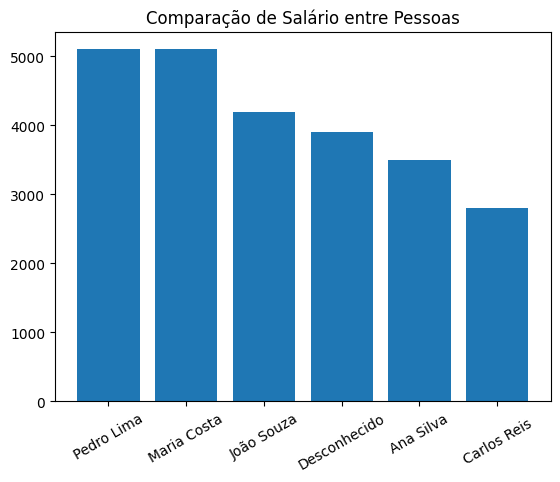

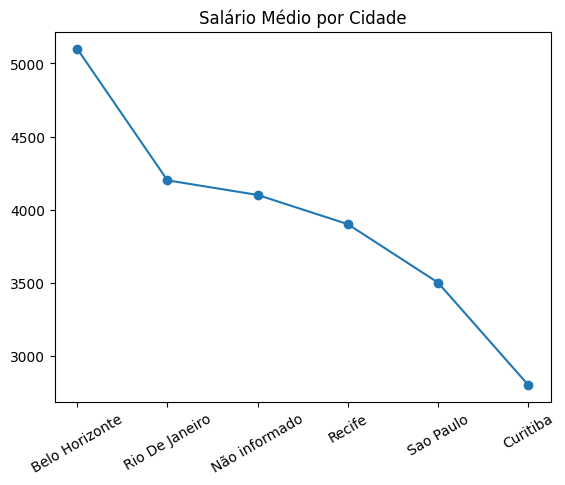

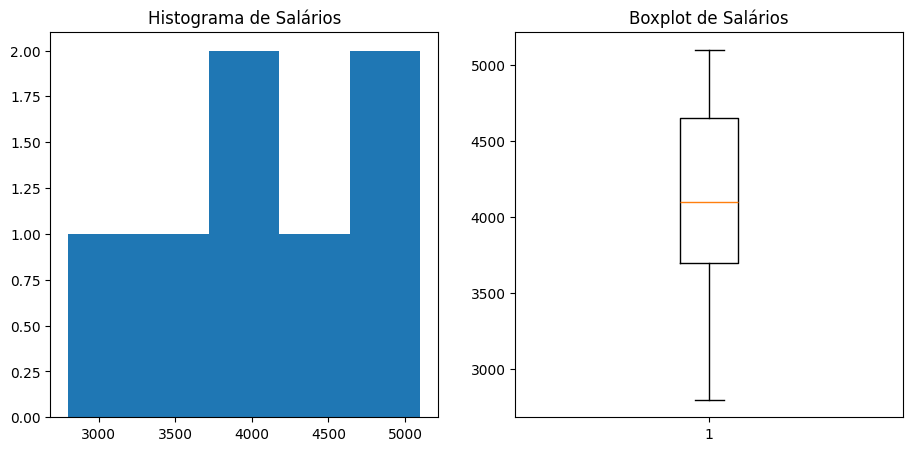

In [29]:
import matplotlib.pyplot as plt

# 1. Comparação entre pessoas (barras)
df_sorted = df.sort_values('Salario', ascending=False)
plt.bar(df_sorted['Nome'], df_sorted['Salario'])
plt.title('Comparação de Salário entre Pessoas')
plt.xticks(rotation=30)
plt.show()

# 2. "Tendência" por cidade (linha com a média)
salario_por_cidade = df.groupby('Cidade')['Salario'].mean().sort_values(ascending=False)
plt.plot(salario_por_cidade.index, salario_por_cidade.values, marker='o')
plt.title('Salário Médio por Cidade')
plt.xticks(rotation=30)
plt.show()

# 3. Distribuição (histograma + boxplot)
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].hist(df['Salario'], bins=5)
axes[0].set_title('Histograma de Salários')
axes[1].boxplot(df['Salario'])
axes[1].set_title('Boxplot de Salários')
plt.show()